In [2]:
# ===== Cell 1：导入库 =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ===== Cell 2：读取所有表 =====
orders = pd.read_csv('data/olist_orders_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')
# geolocation 先不读（100万行，太大，后面需要时再读）

In [4]:
# ===== Cell 3：数据预览 =====
orders.head()  # 查看数据表的前几行
orders.info()  # 查看数据表的基本信息
orders.isnull().sum()  # 查看缺失值
customers.head()
customers.info()
customers.isnull().sum()
order_items.head()
order_items.info()
order_items.isnull().sum()
order_payments.head()
order_payments.info()
order_payments.isnull().sum()
order_reviews.head()
order_reviews.info()
order_reviews.isnull().sum()
products.head()
products.info()
products.isnull().sum()
sellers.head()
sellers.info()
sellers.isnull().sum()
category_translation.head()
category_translation.info()
category_translation.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        

product_category_name            0
product_category_name_english    0
dtype: int64

In [5]:
# ===== Cell 4：日期列转 datetime =====
# orders 表中的时间列：
# - order_purchase_timestamp：用户下单时间
# - order_approved_at：商家确认时间
# - order_delivered_carrier_date：交给物流的时间
# - order_delivered_customer_date：客户签收时间
# - order_estimated_delivery_date：预计送达时间（系统预估的）

date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# reviews 表中的时间列也转一下
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

# order_items 也有一个日期
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [6]:
# ===== Cell 5：订单状态过滤 =====
# 查看有哪些订单状态
orders['order_status'].value_counts()
orders = orders[orders['order_status'] == 'delivered'].copy()

In [7]:
# ===== Cell 6：payments 聚合到订单级别 =====
# 一个订单可能有两种支付方式（比如信用卡+优惠券），需要先聚合
# 否则 JOIN 后行数会翻倍

payments_agg = order_payments.groupby('order_id').agg({
    'payment_value': 'sum',                          # 总支付金额
    'payment_type': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    # ↑ 如果有多种支付方式，取最常见的那个
    'payment_installments': 'max'                    # 最大分期数
}).reset_index()

payments_agg.columns = ['order_id', 'total_payment', 'payment_type', 'max_installments']

In [8]:
# ===== Cell 7：reviews 处理 =====
# 一个订单可能有多种语言的评论（order_id 可能重复，但 review_id 唯一）
# 一般取评分最低的（因为那个才是真实的反馈）或者取最新的

reviews_agg = order_reviews.groupby('order_id').agg({
    'review_score': 'min',         # 如果有多条评论，取最低分（保守）
    'review_comment_message': 'first'  # 评论内容取第一条
}).reset_index()

In [9]:
# ===== Cell 8：核心 JOIN 链 =====
# 以 order_items 为起点（因为它是事实表，一行=一个商品项）
# 逐步 JOIN 其他表

df = order_items.merge(orders, on='order_id', how='left')
df = df.merge(products[['product_id', 'product_category_name', 'product_weight_g',
                         'product_length_cm', 'product_height_cm', 'product_width_cm']],
              on='product_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')
df = df.merge(customers[['customer_id', 'customer_unique_id',
                          'customer_city', 'customer_state']],
              on='customer_id', how='left')
df = df.merge(payments_agg, on='order_id', how='left')
df = df.merge(reviews_agg, on='order_id', how='left')
df = df.merge(sellers[['seller_id', 'seller_city', 'seller_state']],
              on='seller_id', how='left')
# 看下最终宽表大小
print(f"最终数据：{df.shape[0]} 行, {df.shape[1]} 列")
df.head()  # 查看前几行
df.info()

最终数据：112650 行, 30 列
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  str           
 3   seller_id                      112650 non-null  str           
 4   shipping_limit_date            112650 non-null  datetime64[us]
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   customer_id                    110197 non-null  str           
 8   order_status                   110197 non-null  str           
 9   order_purchase_timestamp       110197 non-null  datetime64[us]
 10  order_approved_at              110182 non-null  datetime64[

In [10]:
# ===== Cell 9：新增计算列 =====
# 物流时效
df['delivery_days'] = (df['order_delivered_customer_date'] -
                        df['order_purchase_timestamp']).dt.days

# 是否延迟送达（实际 > 预估）
df['delivery_delayed'] = (
    df['order_delivered_customer_date'] > df['order_estimated_delivery_date']
)

# 订单所属年月
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# 商品总价 = 单价 + 运费
df['item_total'] = df['price'] + df['freight_value']

# 每行一个唯一标识（用于后续分析）
df['item_id'] = df['order_id'] + '_' + df['order_item_id'].astype(str)

In [11]:
# ===== Cell 10：数据验证  =====
# 验证1：最终行数是否等于 order_items 的行数？
# 我们以 order_items 为起点，所有 JOIN 都是 left join，
# 如果 left join 没产生重复匹配，最终行数应该 = order_items 原始行数
print(f"order_items 原始行数: {len(order_items)}")
print(f"JOIN 后宽表行数: {len(df)}")
print(f"行数是否一致: {len(df) == len(order_items)}")
# 如果行数多了 → 某个 JOIN 产生了重复匹配（一对多），需要排查
# 验证2：payment_value 的合计是否保持一致？
# payments 表先聚合了，所以 JOIN 到宽表后 payment_value 的合计不应变
original_payment_sum = order_payments['payment_value'].sum()
joined_payment_sum = df['total_payment'].sum()
print(f"\n原始 payment_value 合计: R$ {original_payment_sum:,.2f}")
print(f"JOIN 后 total_payment 合计: R$ {joined_payment_sum:,.2f}")
print(f"差异: R$ {joined_payment_sum - original_payment_sum:,.2f}")
# 如果差异大 → payments 聚合或 JOIN 有问题
# 验证3：price + freight_value 合计是否一致？
# 这两个字段来自 order_items 表，left join 不会改变它们
original_price_sum = order_items['price'].sum()
original_freight_sum = order_items['freight_value'].sum()
joined_price_sum = df['price'].sum()
joined_freight_sum = df['freight_value'].sum()
print(f"\n原始 price 合计: R$ {original_price_sum:,.2f}")
print(f"JOIN 后 price 合计: R$ {joined_price_sum:,.2f}")
print(f"原始 freight_value 合计: R$ {original_freight_sum:,.2f}")
print(f"JOIN 后 freight_value 合计: R$ {joined_freight_sum:,.2f}")

order_items 原始行数: 112650
JOIN 后宽表行数: 112650
行数是否一致: True

原始 payment_value 合计: R$ 16,008,872.12
JOIN 后 total_payment 合计: R$ 20,308,134.71
差异: R$ 4,299,262.59

原始 price 合计: R$ 13,591,643.70
JOIN 后 price 合计: R$ 13,591,643.70
原始 freight_value 合计: R$ 2,251,909.54
JOIN 后 freight_value 合计: R$ 2,251,909.54


In [12]:
# 验证4：每个 order_id 是否还保留了正确的行数？
# 每个订单在 order_items 中有几行，JOIN 后就该有几行
items_per_order_original = order_items.groupby('order_id').size()
items_per_order_joined = df.groupby('order_id').size()
# 比较两个 Series 是否完全一致
rows_match = (items_per_order_original == items_per_order_joined).all()
print(f"\n每个订单的行数是否和原始一致: {rows_match}")
if not rows_match:
    diff = (items_per_order_original - items_per_order_joined).abs()
    print(f"  不一致的订单数: {(diff > 0).sum()}")
    print(f"  最大差异行数: {diff.max()}")


每个订单的行数是否和原始一致: True


In [13]:
# 验证5：customer_unique_id 是否可能错误地去重了？
# 一个 customer_unique_id 可能有多个 customer_id（同一人多账号）
# 我们 JOIN 用的是 customer_id，不应该丢失任何记录
n_customers_original = customers['customer_unique_id'].nunique()
n_customers_joined = df['customer_unique_id'].nunique()
print(f"\n原始唯一客户数: {n_customers_original}")
print(f"JOIN 后唯一客户数: {n_customers_joined}")
# 如果 JOIN 后的客户数远小于原始 → 有些客户没订单，被 left join 过滤掉了（符合预期）
# 如果 JOIN 后的客户数和原始接近 → 正常，因为 left join 只保留了在 delivered 订单中的客户

print("\n===== 验证通过！可以继续分析 =====")



原始唯一客户数: 96096
JOIN 后唯一客户数: 93358

===== 验证通过！可以继续分析 =====


In [14]:
# ===== Cell 11：缺失值检查 =====

# 步骤1：每列缺失值统计（最关键的一步）
print("===== 各列缺失值统计 =====")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_Pct': missing_pct})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))
# 步骤2：对每种缺失"分类处理"，而不是一刀切 fillna
# 品类缺失 → 填 'unknown'，单独统计"未知品类"的规模
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')
print(f"\n品类为 unknown 的行数: {(df['product_category_name_english'] == 'unknown').sum()}")
print(f"占总数: {(df['product_category_name_english'] == 'unknown').sum() / len(df) * 100:.2f}%")

===== 各列缺失值统计 =====
                               Missing_Count  Missing_Pct
review_comment_message                 65179        57.86
order_approved_at                       2468         2.19
delivery_days                           2461         2.18
order_delivered_customer_date           2461         2.18
order_delivered_carrier_date            2455         2.18
customer_id                             2453         2.18
order_status                            2453         2.18
customer_state                          2453         2.18
customer_city                           2453         2.18
customer_unique_id                      2453         2.18
purchase_month                          2453         2.18
order_estimated_delivery_date           2453         2.18
order_purchase_timestamp                2453         2.18
product_category_name_english           1627         1.44
product_category_name                   1603         1.42
review_score                             942        

In [15]:
# 评分缺失 → 不填充，单独分析"没评分的订单"有什么特征
# （比如：delivery_days 更长？价格更低？）
no_review = df['review_score'].isnull().sum()
print(f"\n无评分的行数: {no_review} ({no_review / len(df) * 100:.1f}%)")
# 这些行在评分相关分析中需要排除，但保留在 GMV/订单量等分析中


无评分的行数: 942 (0.8%)


In [16]:
# 其他维度字段（city/state）缺失量极少 → 直接删行
before = len(df)
df = df.dropna(subset=['customer_state', 'seller_state'])
print(f"删除 state 为空的行: {before - len(df)} 行")
# 通常没有或只有几行

删除 state 为空的行: 2453 行


In [17]:
# ===== Cell 12：异常值检测 =====

# 步骤1：数值列的整体分布（建立直觉）
print("===== 数值列描述性统计 =====")
numeric_cols = ['price', 'freight_value', 'item_total', 'total_payment',
                'delivery_days', 'review_score', 'product_weight_g']
print(df[numeric_cols].describe().round(2))

===== 数值列描述性统计 =====
           price  freight_value  item_total  total_payment  delivery_days  \
count  110197.00      110197.00   110197.00      110194.00      110189.00   
mean      119.98          19.95      139.93         179.47          12.01   
std       182.30          15.70      189.32         271.34           9.45   
min         0.85           0.00        6.08           9.59           0.00   
25%        39.90          13.08       55.18          65.60           6.00   
50%        74.90          16.26       92.13         114.34          10.00   
75%       134.17          21.15      157.51         194.96          15.00   
max      6735.00         409.68     6929.31       13664.08         209.00   

       review_score  product_weight_g  
count     109370.00         110179.00  
mean           4.08           2089.68  
std            1.35           3741.61  
min            1.00              0.00  
25%            4.00            300.00  
50%            5.00            700.00  
75%  

In [18]:
# 步骤2：price 异常值
# Olist 是电商平台，单个商品价格 > 5000 雷亚尔大概率是 B2B 或数据错误
price_outliers = df[df['price'] > 5000]
print(f"\nprice > 5000 的行数: {len(price_outliers)}")
if len(price_outliers) > 0:
    print(price_outliers[['order_id', 'product_id', 'price', 'product_category_name_english']].head())


price > 5000 的行数: 3
                                order_id                        product_id  \
3556    0812eb902a67711a1cb742b3cdaa65ae  489ae2aa008f021502940f251d4cce7f   
107841  f5136e38d1a14a4dbd87dff67da82701  1bdf5e6731585cf01aa8169c7028d6ad   
112233  fefacc66af859508bf1a7934eab1e97f  69c590f7ffc7bf8db97190b6cb6ed62e   

         price product_category_name_english  
3556    6735.0                    housewares  
107841  6499.0                           art  
112233  6729.0                     computers  


In [19]:
# 步骤3：freight_value 异常值
# 运费 > 200 雷亚尔很罕见（除非是大件家具）
freight_outliers = df[df['freight_value'] > 200]
print(f"\nfreight_value > 200 的行数: {len(freight_outliers)}")


freight_value > 200 的行数: 66


In [20]:
# 步骤4：delivery_days 异常值
# 负数 = 送达日期早于下单日期 → 数据错误（虽然在 delivered 状态几乎不会出现）
neg_delivery = df[df['delivery_days'] < 0]
print(f"\ndelivery_days < 0 的行数: {len(neg_delivery)}")


delivery_days < 0 的行数: 0


In [21]:
# delivery_days > 100 → 可能数据错误或极端偏远地区
extreme_delivery = df[df['delivery_days'] > 100]
print(f"delivery_days > 100 的行数: {len(extreme_delivery)}")
# 建议：保留但标注。巴西太偏远的地区配送确实可能超过 3 个月

delivery_days > 100 的行数: 68


In [22]:
# 步骤5：过滤明确异常的数据
before = len(df)
# 过滤 price <= 0（不可能免费卖东西）
df = df[df['price'] > 0]
# 过滤 freight_value < 0（运费不可能为负）
df = df[df['freight_value'] >= 0]
# 过滤 delivery_days < 0（送达不可能早于下单）
df = df[df['delivery_days'] >= 0]
print(f"\n过滤异常数据: {before - len(df)} 行被删除")
print(f"过滤后数据: {len(df)} 行 × {df.shape[1]} 列")


过滤异常数据: 8 行被删除
过滤后数据: 110189 行 × 35 列


In [23]:
# 1. 时间和规模
start_date = df['order_purchase_timestamp'].min()
end_date = df['order_purchase_timestamp'].max()
total_months = round((end_date - start_date).days / 30.44, 1)  # 平均每月天数

In [24]:
# 2. 订单、商品、客户
n_orders = df['order_id'].nunique()            # 多少个独立订单
n_items = len(df)                               # 总商品行数（每行=一个订单-商品）
n_customers = df['customer_unique_id'].nunique() # 多少个自然人
n_sellers = df['seller_id'].nunique()           # 多少个卖家

In [25]:
# 3. 金额
total_gmv = df['item_total'].sum()              # GMV = 商品价格 + 运费
total_revenue = df['price'].sum()                # 纯商品收入（不含运费）
total_freight = df['freight_value'].sum()        # 总运费
avg_order_value = total_gmv / n_orders           # 平均客单价
avg_item_price = df['price'].mean()              # 平均单品价格

In [26]:
# 4. 物流
avg_delivery_days = df['delivery_days'].mean()   # 平均配送天数
median_delivery_days = df['delivery_days'].median() # 中位配送天数（比均值更稳健）
delay_rate = df['delivery_delayed'].mean() * 100  # 超时率（%）

In [27]:
# 5. 评分
avg_score = df['review_score'].dropna().mean()    # 平均评分（排除无评价的）
score_1_2_pct = (df['review_score'].dropna() <= 2).mean() * 100  # 差评率

In [28]:
# 6. 品类和产品
n_categories = df['product_category_name_english'].nunique()  # 有多少种品类
n_products = df['product_id'].nunique()                       # 有多少个 SKU

In [29]:

# 格式化输出
print("=" * 55)
print("   🏪 Olist 巴西电商平台 — 数据概览")
print("=" * 55)
print(f"   📅 时间范围      {start_date.date()} → {end_date.date()}（约 {total_months} 个月）")
print(f"   📦 总订单数       {n_orders:>12,}")
print(f"   📋 总商品行数     {n_items:>12,}（含同一订单多商品）")
print(f"   👥 总客户数       {n_customers:>12,}（自然人，customer_unique_id）")
print(f"   🏪 总卖家数       {n_sellers:>12,}")
print(f"   📂 品类数         {n_categories:>12}")
print("-" * 55)
print(f"   💰 总 GMV         R$ {total_gmv:>11,.0f}（价格+运费）")
print(f"   💵 商品收入       R$ {total_revenue:>11,.0f}")
print(f"   🚚 总运费         R$ {total_freight:>11,.0f}")
print(f"   🛒 平均客单价     R$ {avg_order_value:>11,.2f}（每笔订单）")
print(f"   🏷️  平均单品价格   R$ {avg_item_price:>11,.2f}")
print("-" * 55)
print(f"   🚀 平均配送       {avg_delivery_days:>11.1f} 天（中位: {median_delivery_days:.0f} 天）")
print(f"   ⚠️  超时率         {delay_rate:>11.1f}%")
print(f"   ⭐ 平均评分       {avg_score:>11.2f} / 5.0")
print(f"   👎 差评率(1-2分)  {score_1_2_pct:>11.1f}%")
print("=" * 55)

   🏪 Olist 巴西电商平台 — 数据概览
   📅 时间范围      2016-09-15 → 2018-08-29（约 23.4 个月）
   📦 总订单数             96,470
   📋 总商品行数          110,189（含同一订单多商品）
   👥 总客户数             93,350（自然人，customer_unique_id）
   🏪 总卖家数              2,970
   📂 品类数                   72
-------------------------------------------------------
   💰 总 GMV         R$  15,418,395（价格+运费）
   💵 商品收入       R$  13,220,249
   🚚 总运费         R$   2,198,146
   🛒 平均客单价     R$      159.83（每笔订单）
   🏷️  平均单品价格   R$      119.98
-------------------------------------------------------
   🚀 平均配送              12.0 天（中位: 10 天）
   ⚠️  超时率                 7.9%
   ⭐ 平均评分              4.08 / 5.0
   👎 差评率(1-2分)         14.8%


In [30]:
# ===== Cell 14：月度聚合 — GMV、订单量、客单价 =====

# 步骤1：按月聚合三个核心指标
# purchase_month 在 Day 10 Cell 9 中已创建
monthly = df.groupby('purchase_month').agg({
    'order_id': 'nunique',              # 独立订单数
    'item_total': 'sum',                # 月度 GMV（价格+运费）
    'customer_unique_id': 'nunique',    # 月度活跃客户数
    'price': 'sum'                      # 纯商品收入
}).reset_index()

# 重命名
monthly.columns = ['Month', 'Orders', 'GMV', 'ActiveCustomers', 'Revenue']
# 计算客单价 = GMV / 订单数
monthly['AvgOrderValue'] = monthly['GMV'] / monthly['Orders']

# Month 转字符串（matplotlib 的 x 轴标签）
monthly['Month'] = monthly['Month'].astype(str)
# 步骤2：过滤不完整的月份
# 2016-09：数据从 9 月中旬开始 → 首月不完整
# 2018-10：数据到 10 月中旬 → 末月不完整
# 这两个月的 GMV/订单量会被严重低估，需要在图上标注
print("首尾月份（数据不完整）:")
print(f"  首月: {monthly['Month'].iloc[0]}（只有 {monthly['Orders'].iloc[0]} 单）")
print(f"  尾月: {monthly['Month'].iloc[-1]}（只有 {monthly['Orders'].iloc[-1]} 单）")
print(f"\n完整月份的月度平均:")
full_months = monthly.iloc[1:-1]  # 去掉首尾
print(f"  月均订单: {full_months['Orders'].mean():,.0f}")
print(f"  月均 GMV: R$ {full_months['GMV'].mean():,.0f}")
print(f"  月均活跃客户: {full_months['ActiveCustomers'].mean():,.0f}")

首尾月份（数据不完整）:
  首月: 2016-09（只有 1 单）
  尾月: 2018-08（只有 6351 单）

完整月份的月度平均:
  月均订单: 4,291
  月均 GMV: R$ 687,274
  月均活跃客户: 4,232


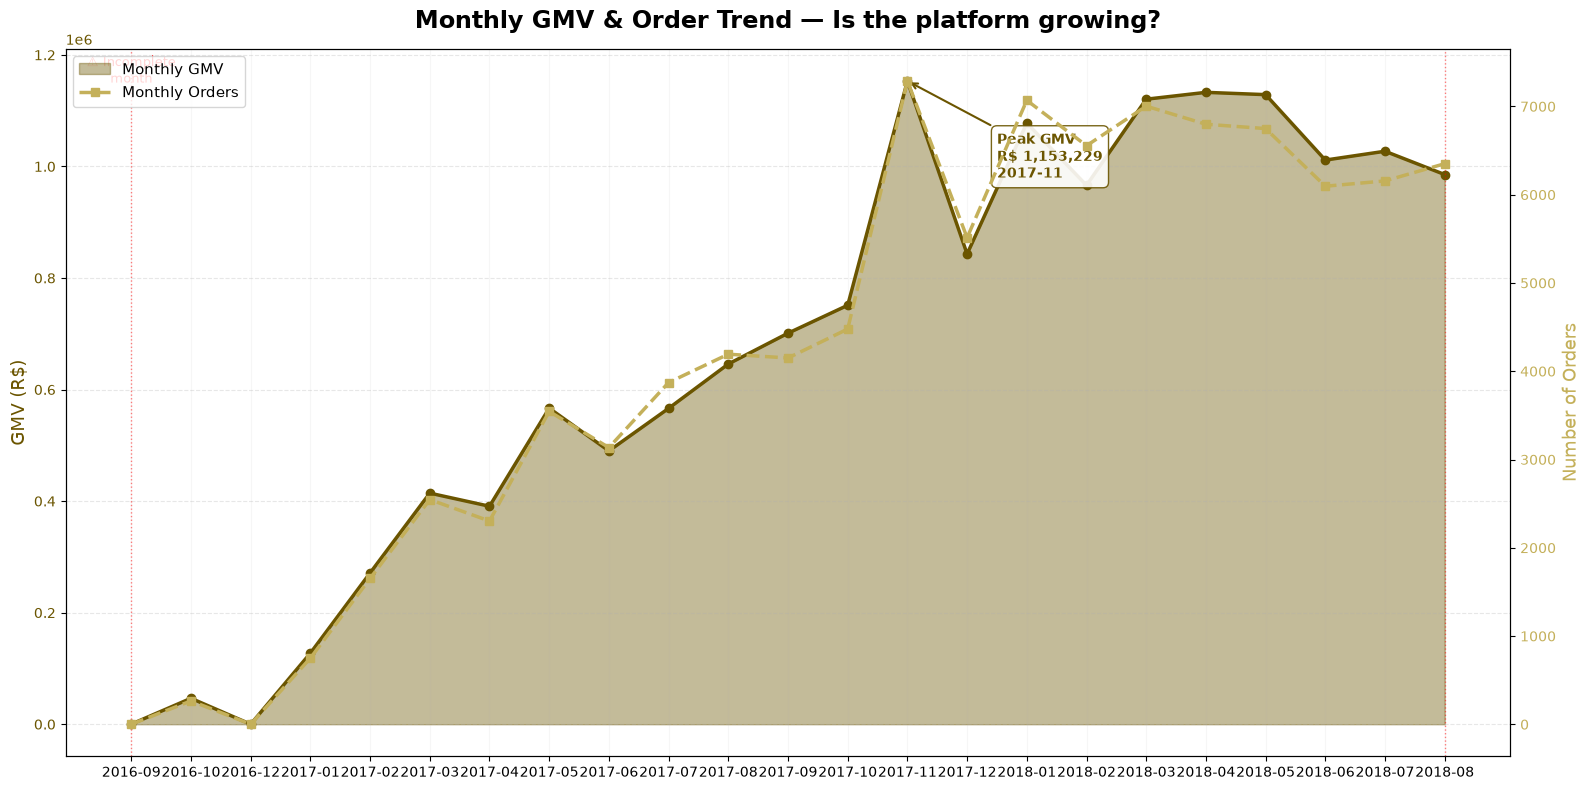

In [31]:
# ===== Cell 15：月度趋势双轴图 — GMV（面积）+ 订单量（折线） =====

fig, ax1 = plt.subplots(figsize=(16, 8))

# 颜色系统
gmv_color = '#6b5500'
order_color = '#c4b05a'

# --- 左轴：GMV 面积图 ---
x = range(len(monthly))
ax1.fill_between(x, monthly['GMV'], alpha=0.4, color=gmv_color, label='Monthly GMV')
ax1.plot(x, monthly['GMV'], color=gmv_color, linewidth=2.5, marker='o', markersize=6)
ax1.set_ylabel('GMV (R$)', fontsize=13, color=gmv_color)
ax1.tick_params(axis='y', labelcolor=gmv_color)

# --- 右轴：订单量折线 ---
ax2 = ax1.twinx()
ax2.plot(x, monthly['Orders'], color=order_color, linewidth=2.5,
         marker='s', markersize=6, linestyle='--', label='Monthly Orders')
ax2.set_ylabel('Number of Orders', fontsize=13, color=order_color)
ax2.tick_params(axis='y', labelcolor=order_color)

# --- x 轴 ---
# 隔月标注，避免标签重叠
step = max(1, len(monthly) // 12)
plt.xticks(x[::step], monthly['Month'][::step], rotation=45, ha='right', fontsize=10)

# --- 峰值标注 ---
gmv_peak_idx = monthly['GMV'].idxmax()
ax1.annotate(
    f"Peak GMV\nR$ {monthly.loc[gmv_peak_idx, 'GMV']:,.0f}\n{monthly.loc[gmv_peak_idx, 'Month']}",
    xy=(gmv_peak_idx, monthly.loc[gmv_peak_idx, 'GMV']),
    xytext=(gmv_peak_idx + 1.5, monthly.loc[gmv_peak_idx, 'GMV'] * 0.85),
    fontsize=10, fontweight='bold', color=gmv_color,
    arrowprops=dict(arrowstyle='->', color=gmv_color, lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=gmv_color, alpha=0.9)
)

# --- 标注不完整月份 ---
for idx in [0, len(monthly) - 1]:
    ax1.axvline(x=idx, color='red', linestyle=':', alpha=0.5, linewidth=1)
ax1.text(0, ax1.get_ylim()[1] * 0.95, '⚠ Incomplete\nmonth',
         ha='center', fontsize=9, color='red', alpha=0.8)

# --- 图例 ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

ax1.set_title('Monthly GMV & Order Trend — Is the platform growing?',
              fontsize=17, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
# x 轴也加淡网格
ax1.grid(axis='x', alpha=0.1, linestyle='-')

plt.tight_layout()
plt.show()

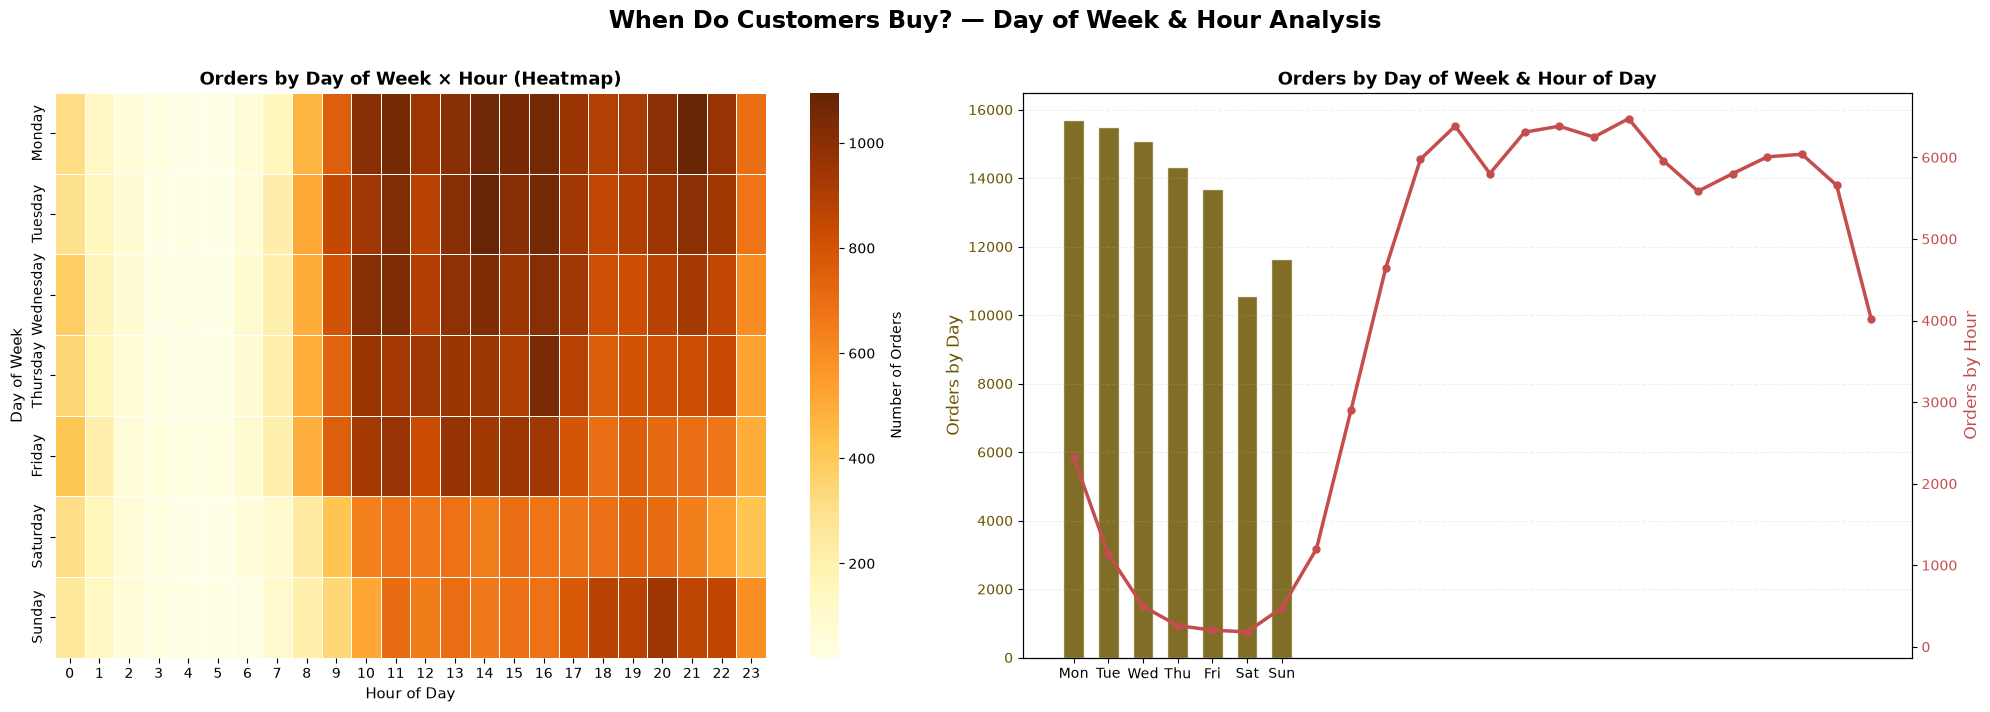

In [32]:
# ===== Cell 16：星期 × 小时热力分布 — 什么时候下单最多？ =====

# 步骤1：创建星期和小时维度
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
df['hour'] = df['order_purchase_timestamp'].dt.hour

# 步骤2：星期 × 小时交叉表
# 行 = 星期几，列 = 小时（0-23），值 = 订单数
dow_hour = df.groupby(['day_of_week', 'hour'])['order_id'].nunique().unstack()

# 步骤3：固定星期顺序（从周一到周日）
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']
dow_hour = dow_hour.reindex(day_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('When Do Customers Buy? — Day of Week & Hour Analysis',
             fontsize=17, fontweight='bold', y=1.01)
# --- 左图：星期 × 小时热力图 ---
sns.heatmap(
    dow_hour,
    annot=False, cmap='YlOrBr',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Number of Orders'},
    ax=ax1
)
ax1.set_title('Orders by Day of Week × Hour (Heatmap)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Day of Week', fontsize=11)

# --- 右图：星期汇总 + 小时汇总 ---
# 星期汇总
dow_total = df.groupby('day_of_week')['order_id'].nunique().reindex(day_order)
# 小时汇总
hour_total = df.groupby('hour')['order_id'].nunique()

# 用两个子区域
ax2_top = ax2
ax2_bottom = ax2.twinx()

# 星期柱状图
bars = ax2_top.bar(range(len(dow_total)), dow_total.values,
                   color='#6b5500', edgecolor='white', alpha=0.85, width=0.6)
ax2_top.set_xticks(range(len(dow_total)))
ax2_top.set_xticklabels([d[:3] for d in day_order], fontsize=10)
ax2_top.set_ylabel('Orders by Day', fontsize=12, color='#6b5500')
ax2_top.tick_params(axis='y', labelcolor='#6b5500')

# 小时折线
ax2_bottom.plot(range(24), hour_total.values, color='#c44e4e',
                linewidth=2.5, marker='o', markersize=5)
ax2_bottom.set_ylabel('Orders by Hour', fontsize=12, color='#c44e4e')
ax2_bottom.tick_params(axis='y', labelcolor='#c44e4e')
ax2_bottom.set_xlabel('Hour of Day (0-23)', fontsize=11)

ax2_top.set_title('Orders by Day of Week & Hour of Day',
                  fontsize=13, fontweight='bold')
ax2_top.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()
# 关键发现：
# - 工作日和周末的购买时段差异大吗？（工作日白天多 vs 周末晚间多）
# - 峰值在几点？如果峰值在晚上 8-10 点 → 推送消息安排在晚上
# - 如果周日低迷 → 说明巴西电商周末消费冲动不强（和国内不同）

In [33]:
# ===== Cell 17：按客户所在州聚合 =====

# 步骤1：按 customer_state 多维度聚合
state_analysis = df.groupby('customer_state').agg({
    'order_id': 'nunique',              # 订单数
    'item_total': 'sum',                # GMV
    'customer_unique_id': 'nunique',    # 客户数
    'review_score': 'mean',             # 平均评分
    'delivery_days': 'mean'             # 平均配送天数
}).round(2)
state_analysis.columns = ['Orders', 'GMV', 'Customers', 'AvgScore', 'AvgDeliveryDays']
# 计算客单价和人均消费
state_analysis['AvgOrderValue'] = (state_analysis['GMV'] / state_analysis['Orders']).round(2)
state_analysis['RevenuePerCustomer'] = (state_analysis['GMV'] / state_analysis['Customers']).round(2)
# 计算占比
state_analysis['GMV_Pct'] = (state_analysis['GMV'] / state_analysis['GMV'].sum() * 100).round(1)
# 按 GMV 降序排列
state_analysis = state_analysis.sort_values('GMV', ascending=False)

print("===== Top 10 州 GMV 排名 =====")
print(state_analysis.head(10).to_string())

===== Top 10 州 GMV 排名 =====
                Orders         GMV  Customers  AvgScore  AvgDeliveryDays  AvgOrderValue  RevenuePerCustomer  GMV_Pct
customer_state                                                                                                      
SP               40494  5768518.23      39149      4.18             8.26         142.45              147.35     37.4
RJ               12350  2055401.57      11917      3.87            14.69         166.43              172.48     13.3
MG               11354  1818891.67      11001      4.12            11.51         160.20              165.34     11.8
RS                5344   861278.79       5167      4.09            14.71         161.17              166.69      5.6
PR                4923   781708.80       4769      4.14            11.48         158.79              163.91      5.1
SC                3546   595127.78       3449      4.05            14.52         167.83              172.55      3.9
BA                3256   591137.81  

In [34]:
# 步骤2：集中度分析
top1_pct = state_analysis.iloc[0]['GMV_Pct']
top3_pct = state_analysis.head(3)['GMV_Pct'].sum()
top5_pct = state_analysis.head(5)['GMV_Pct'].sum()
print(f"\n市场集中度:")
print(f"  SP（圣保罗）占: {top1_pct:.1f}%")
print(f"  Top 3 州占: {top3_pct:.1f}%")
print(f"  Top 5 州占: {top5_pct:.1f}%")


市场集中度:
  SP（圣保罗）占: 37.4%
  Top 3 州占: 62.5%
  Top 5 州占: 73.2%


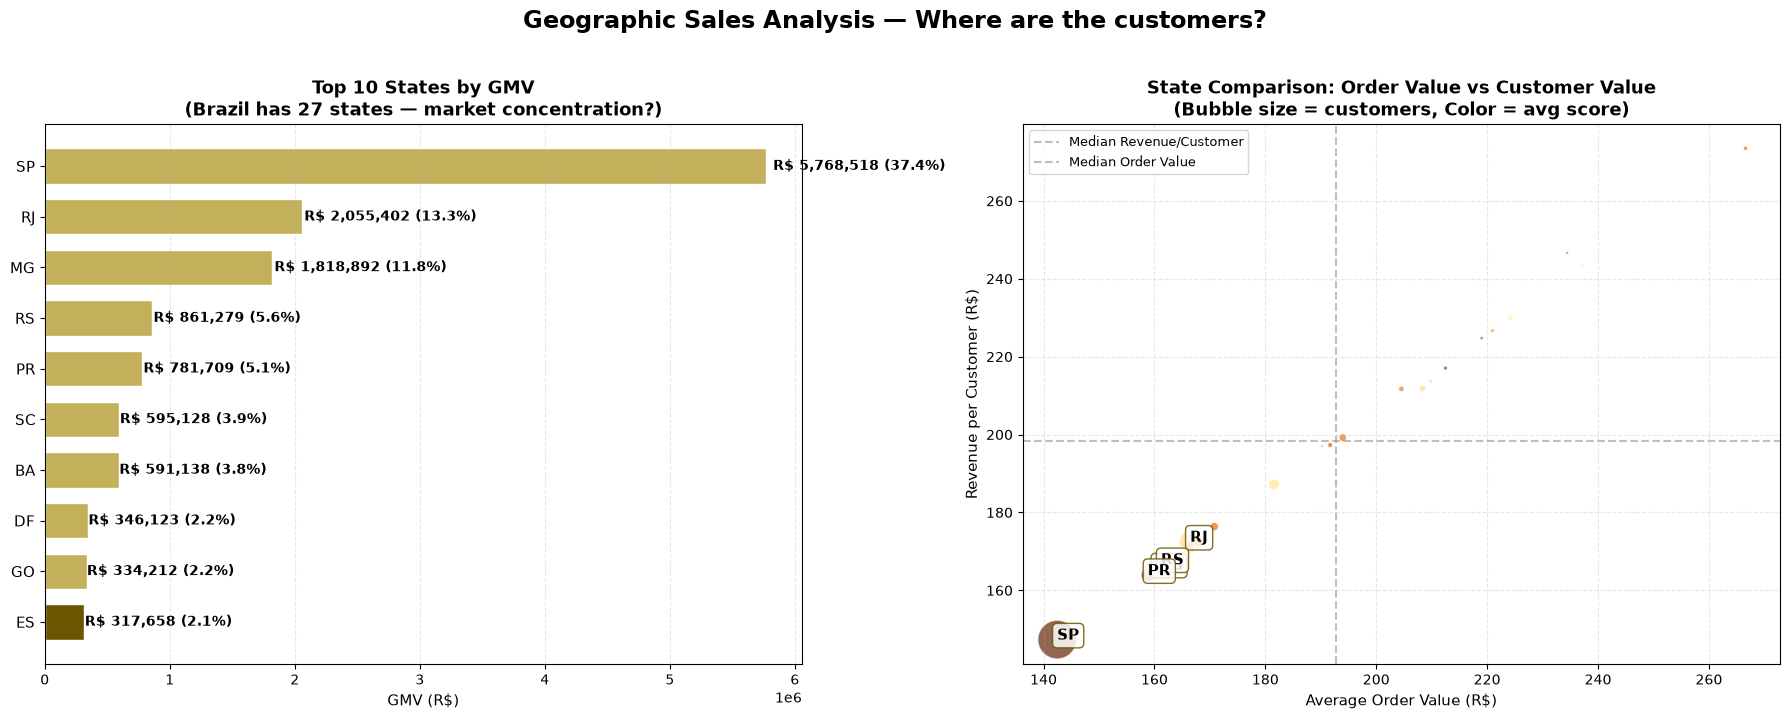

In [35]:
# ===== Cell 18：地理可视化 — Top 10 州 × 客单价双维度对比 =====

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Geographic Sales Analysis — Where are the customers?',
             fontsize=17, fontweight='bold', y=1.02)

highlight = '#6b5500'
secondary = '#c4b05a'

# --- 左图：Top 10 州 GMV 柱状图 ---
top_10 = state_analysis.head(10)
# 水平柱状图：反转顺序，让最大的在最上面
top_10_rev = top_10.iloc[::-1]

colors = [highlight] + [secondary] * (len(top_10_rev) - 1)
bars = ax1.barh(range(len(top_10_rev)), top_10_rev['GMV'],
                color=colors, edgecolor='white', height=0.7)

# 数字标签
for i, (bar, val, pct) in enumerate(zip(bars, top_10_rev['GMV'], top_10_rev['GMV_Pct'])):
    ax1.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
             f'R$ {val:,.0f} ({pct:.1f}%)',
             va='center', fontsize=10, fontweight='bold')

ax1.set_yticks(range(len(top_10_rev)))
ax1.set_yticklabels(top_10_rev.index, fontsize=11)
ax1.set_title('Top 10 States by GMV\n(Brazil has 27 states — market concentration?)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('GMV (R$)', fontsize=11)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# --- 右图：客单价 vs 人均消费 散点图 ---
# 取有足够订单数的州（>=100 单），避免小数据点误导
valid_states = state_analysis[state_analysis['Orders'] >= 100].copy()

ax2.scatter(
    valid_states['AvgOrderValue'], valid_states['RevenuePerCustomer'],
    s=valid_states['Customers'] / 50,  # 气泡大小 = 客户数
    c=valid_states['AvgScore'], cmap='YlOrBr',  # 颜色 = 平均评分
    alpha=0.7, edgecolor='white', linewidth=1
)

# 标注 Top 5 州
for state in top_10.head(5).index:
    if state in valid_states.index:
        ax2.annotate(
            state,
            xy=(valid_states.loc[state, 'AvgOrderValue'],
                valid_states.loc[state, 'RevenuePerCustomer']),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=highlight, alpha=0.85)
        )

ax2.set_xlabel('Average Order Value (R$)', fontsize=11)
ax2.set_ylabel('Revenue per Customer (R$)', fontsize=11)
ax2.set_title('State Comparison: Order Value vs Customer Value\n(Bubble size = customers, Color = avg score)',
              fontsize=13, fontweight='bold')
ax2.axhline(valid_states['RevenuePerCustomer'].median(), color='gray',
            linestyle='--', alpha=0.5, label='Median Revenue/Customer')
ax2.axvline(valid_states['AvgOrderValue'].median(), color='gray',
            linestyle='--', alpha=0.5, label='Median Order Value')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
# 关键发现：
# - SP 一家独大是必然的（人口最多），但有价值的发现是其他人的位置
# - 有些州虽然 GMV 不高但客单价高 → 高净值人群市场
# - 右上角（高客单价 + 高人均消费）的州 → 值得投入营销资源
# - 平均评分低的州 → 可能是物流慢导致的（需要和 delivery_days 交叉验证）

In [36]:
# ===== Cell 19：品类 × 销售额 Top 15 =====

# 步骤1：按品类英文名聚合
category_analysis = df.groupby('product_category_name_english').agg({
    'order_id': 'nunique',           # 订单数
    'item_total': 'sum',             # GMV
    'price': 'mean',                  # 平均单价
    'review_score': 'mean',           # 平均评分
    'delivery_days': 'mean',          # 平均配送天数
    'product_id': 'nunique'           # SKU 数
}).round(2)

category_analysis.columns = ['Orders', 'GMV', 'AvgPrice', 'AvgScore',
                              'AvgDeliveryDays', 'SKU_Count']
category_analysis = category_analysis.sort_values('GMV', ascending=False)

# 计算占比
category_analysis['GMV_Pct'] = (
    category_analysis['GMV'] / category_analysis['GMV'].sum() * 100
).round(1)

print(f"共有 {len(category_analysis)} 个品类")
print(f"\n===== Top 15 品类 GMV 排名 =====")
print(category_analysis.head(15).to_string())

# Others 占比
top15_pct = category_analysis.head(15)['GMV_Pct'].sum()
print(f"\nTop 15 品类占总 GMV: {top15_pct:.1f}%")
print(f"其余 {len(category_analysis) - 15} 个品类占: {100 - top15_pct:.1f}%")
# 如果 Others 占比较高（>30%），说明品类结构长尾分散

共有 72 个品类

===== Top 15 品类 GMV 排名 =====
                               Orders         GMV  AvgPrice  AvgScore  AvgDeliveryDays  SKU_Count  GMV_Pct
product_category_name_english                                                                             
health_beauty                    8647  1412089.53    130.28      4.19            11.52       2397      9.2
watches_gifts                    5493  1264016.98    199.06      4.07            12.19       1300      8.2
bed_bath_table                   9272  1225209.26     93.44      3.92            12.34       2991      7.9
sports_leisure                   7529  1118062.91    113.25      4.16            11.69       2821      7.3
computers_accessories            6529  1032603.65    116.27      3.98            12.78       1599      6.7
furniture_decor                  6307   880329.92     87.25      3.95            12.40       2593      5.7
housewares                       5743   758392.25     90.60      4.11            10.46       2282      4

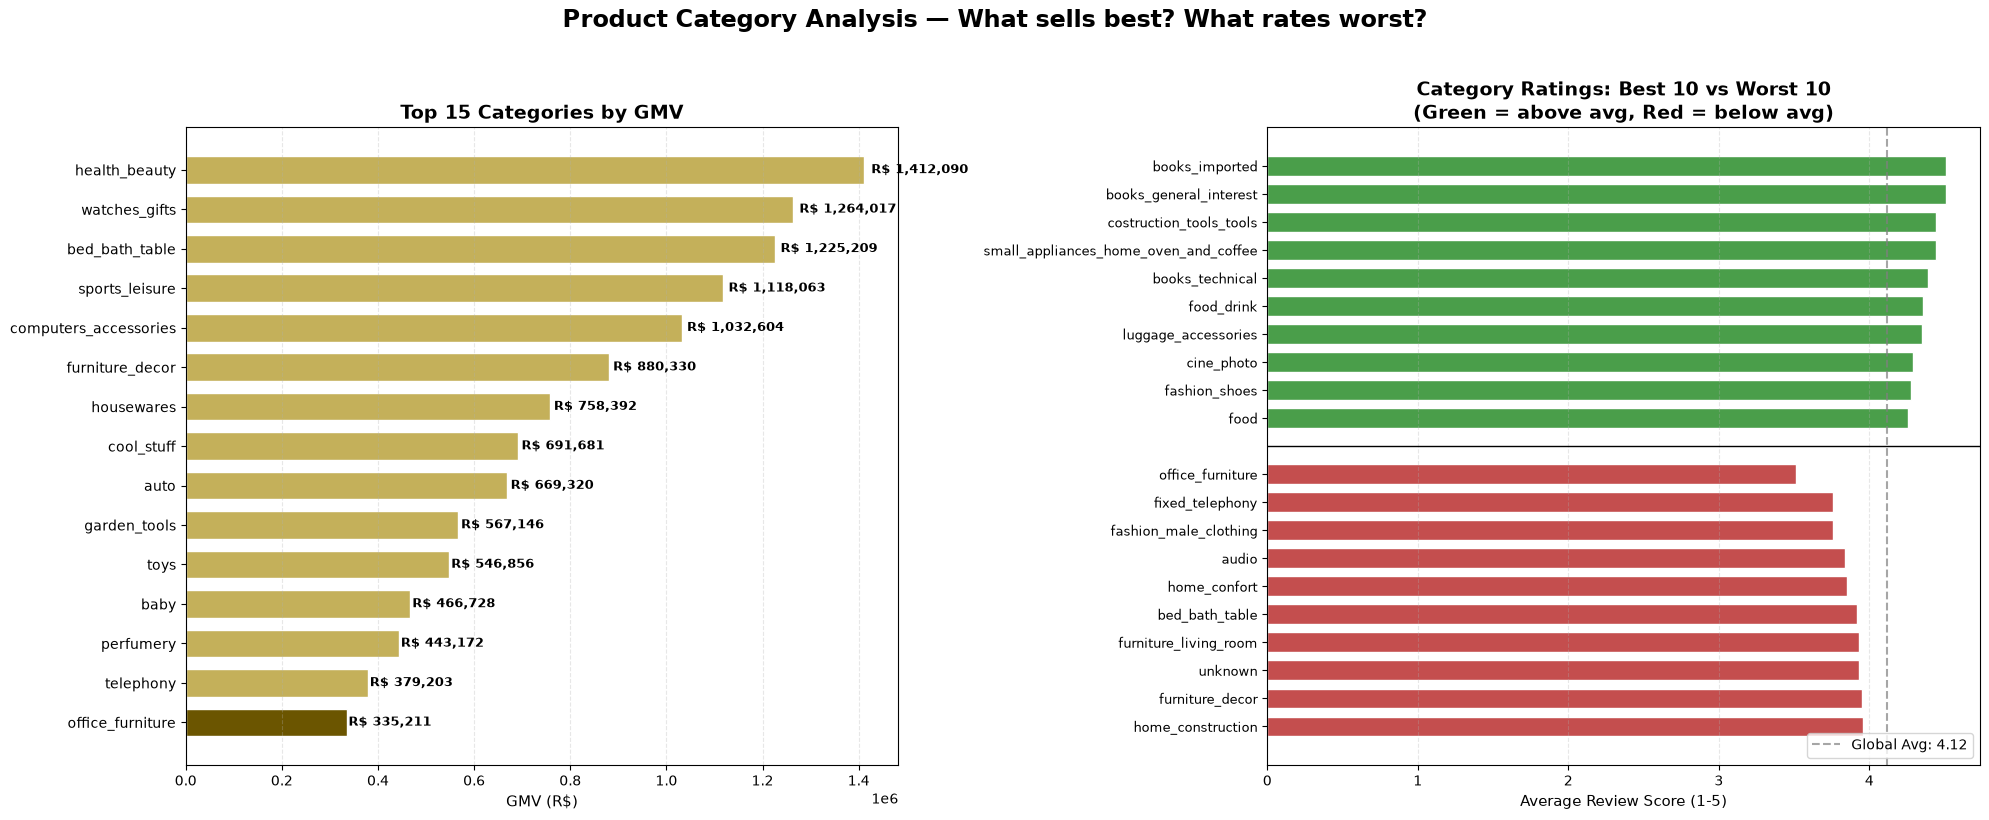

In [37]:
# ===== Cell 20：品类分析 — 双维度排名图 =====

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Product Category Analysis — What sells best? What rates worst?',
             fontsize=17, fontweight='bold', y=1.02)

highlight = '#6b5500'
secondary = '#c4b05a'

# --- 左图：Top 15 品类 GMV 水平柱状图 ---
top_15_cat = category_analysis.head(15).iloc[::-1]  # 反转，Top 1 在上

bars = ax1.barh(range(len(top_15_cat)), top_15_cat['GMV'],
                color=[highlight] + [secondary] * (len(top_15_cat) - 1),
                edgecolor='white', height=0.7)
# 数字标签
for i, (bar, val) in enumerate(zip(bars, top_15_cat['GMV'])):
    ax1.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
             f'R$ {val:,.0f}', va='center', fontsize=9, fontweight='bold')

ax1.set_yticks(range(len(top_15_cat)))
ax1.set_yticklabels(top_15_cat.index, fontsize=10)
ax1.set_title('Top 15 Categories by GMV', fontsize=14, fontweight='bold')
ax1.set_xlabel('GMV (R$)', fontsize=11)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# --- 右图：品类评分 — 好评 Top 10 vs 差评 Top 10 ---
# 只考虑有足够订单数的品类（>=50 单），否则小样本评分不可靠
valid_cats = category_analysis[category_analysis['Orders'] >= 50]

# 好评 Top 10
best_rated = valid_cats.sort_values('AvgScore', ascending=False).head(10)
# 差评 Top 10
worst_rated = valid_cats.sort_values('AvgScore', ascending=True).head(10)

# 合并：好评在上半部分，差评在下半部分
y_positions = list(range(10, 0, -1)) + list(range(-1, -11, -1))
all_cats = list(best_rated.index) + list(worst_rated.index)
all_scores = list(best_rated['AvgScore']) + list(worst_rated['AvgScore'])
colors_list = ['#4a9e4a'] * 10 + ['#c44e4e'] * 10

ax2.barh(y_positions, all_scores, color=colors_list, edgecolor='white', height=0.7)
ax2.set_yticks(y_positions)
ax2.set_yticklabels(all_cats, fontsize=9)
ax2.axvline(valid_cats['AvgScore'].mean(), color='gray',
            linestyle='--', alpha=0.7, label=f'Global Avg: {valid_cats["AvgScore"].mean():.2f}')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Category Ratings: Best 10 vs Worst 10\n(Green = above avg, Red = below avg)',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Average Review Score (1-5)', fontsize=11)
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

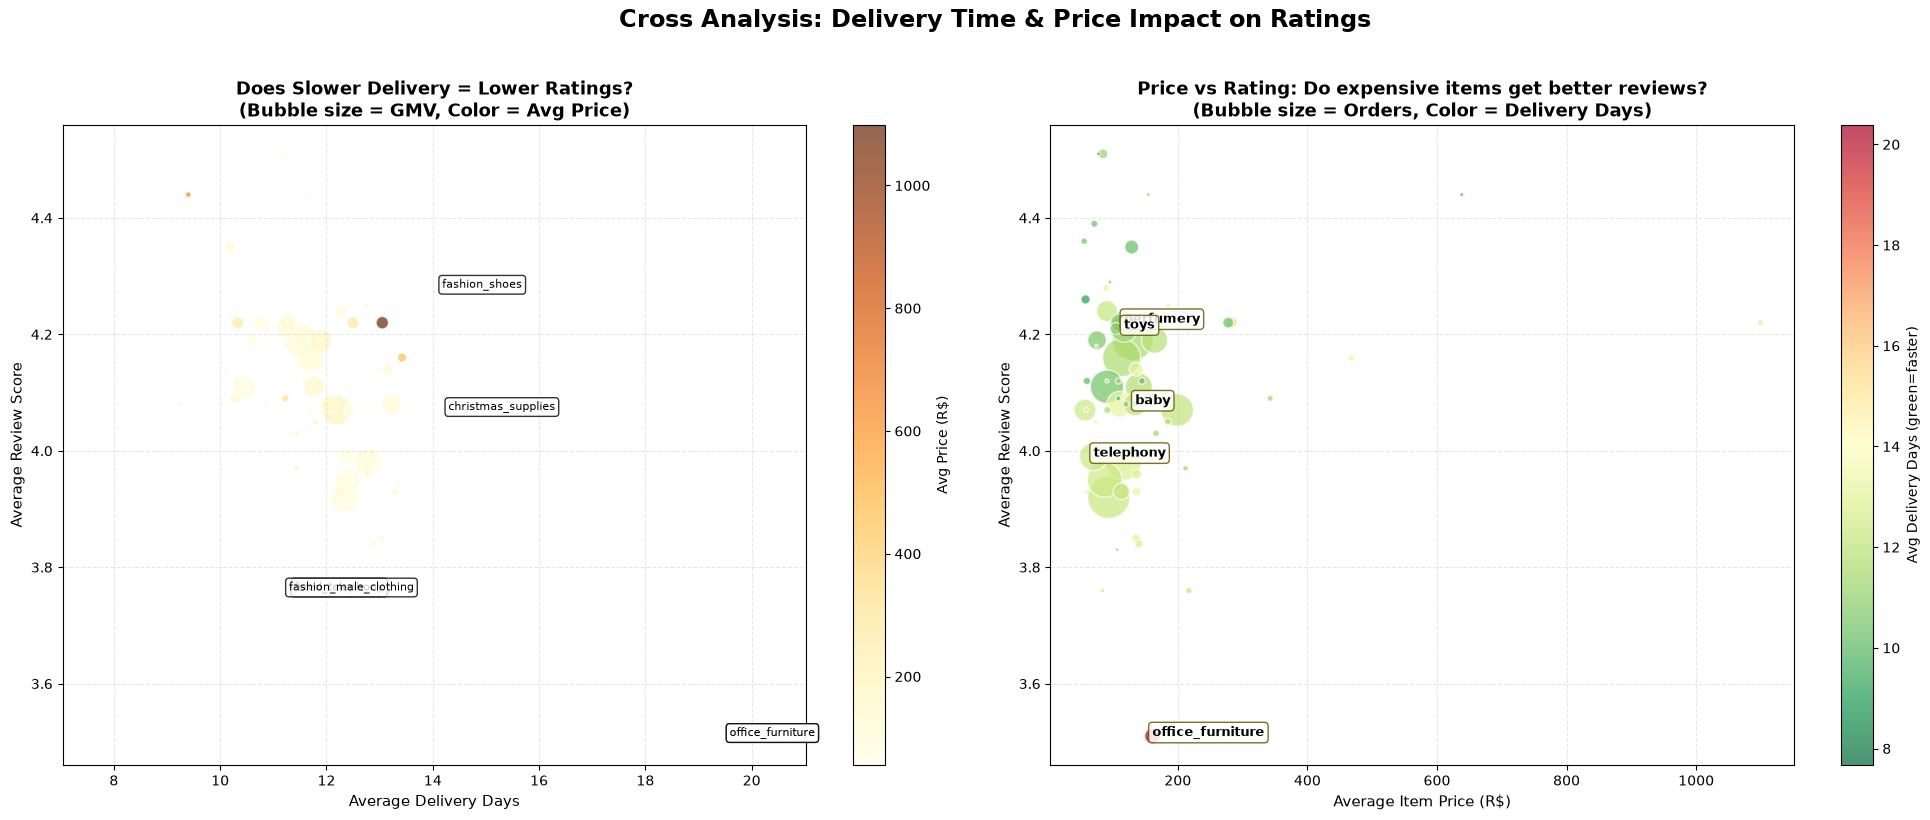

In [38]:
# ===== Cell 21：品类交叉分析 — 配送时效 vs 评分 vs 客单价 =====

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Cross Analysis: Delivery Time & Price Impact on Ratings',
             fontsize=17, fontweight='bold', y=1.02)

# 只取订单数 >= 30 的品类，确保统计稳定
valid = category_analysis[category_analysis['Orders'] >= 30].copy()

# --- 左图：配送天数 vs 评分散点图 ---
# 每个点 = 一个品类
scatter = ax1.scatter(
    valid['AvgDeliveryDays'], valid['AvgScore'],
    s=valid['GMV'] / valid['GMV'].max() * 500,  # 气泡大小 = GMV 规模
    c=valid['AvgPrice'], cmap='YlOrBr',          # 颜色 = 均价
    alpha=0.7, edgecolor='white', linewidth=1
)
# 标注极端品类
for label, row in valid.nlargest(3, 'AvgDeliveryDays').iterrows():
    ax1.annotate(label, xy=(row['AvgDeliveryDays'], row['AvgScore']),
                 fontsize=8, ha='center',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
for label, row in valid.nsmallest(3, 'AvgScore').iterrows():
    ax1.annotate(label, xy=(row['AvgDeliveryDays'], row['AvgScore']),
                 fontsize=8, ha='center',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_xlabel('Average Delivery Days', fontsize=11)
ax1.set_ylabel('Average Review Score', fontsize=11)
ax1.set_title('Does Slower Delivery = Lower Ratings?\n(Bubble size = GMV, Color = Avg Price)',
              fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Avg Price (R$)', fontsize=10)
ax1.grid(alpha=0.3, linestyle='--')

# --- 右图：品类价格带 + 评分气泡图 ---
# x 轴 = 平均单价，y 轴 = 平均评分
scatter2 = ax2.scatter(
    valid['AvgPrice'], valid['AvgScore'],
    s=valid['Orders'] / 10,               # 气泡大小 = 订单量
    c=valid['AvgDeliveryDays'], cmap='RdYlGn_r',  # 颜色：红=慢，绿=快
    alpha=0.7, edgecolor='white', linewidth=1
)
# 标注 Top 5 GMV 品类
for label in top_15_cat.head(5).index:
    if label in valid.index:
        row = valid.loc[label]
        ax2.annotate(
            label, xy=(row['AvgPrice'], row['AvgScore']),
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=highlight, alpha=0.85)
        )

ax2.set_xlabel('Average Item Price (R$)', fontsize=11)
ax2.set_ylabel('Average Review Score', fontsize=11)
ax2.set_title('Price vs Rating: Do expensive items get better reviews?\n(Bubble size = Orders, Color = Delivery Days)',
              fontsize=13, fontweight='bold')
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Avg Delivery Days (green=faster)', fontsize=10)
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [39]:
# ===== Cell 22：RFM 计算 — Olist 版本 =====

# 步骤1：分析基准日
analysis_date = df['order_purchase_timestamp'].max() + timedelta(days=1)
print(f"Olist 分析基准日: {analysis_date.date()}")

# 步骤2：按 customer_unique_id 聚合 R/F/M
# 关键区别：用 customer_unique_id 而不是 customer_id！
# 同一个自然人可能换设备重新注册 → 多个 customer_id
# 如果用 customer_id → 一个忠实客户被拆成多个"普通客户" → RFM 全错
rfm = df.groupby('customer_unique_id').agg({
    # R：距基准日有多少天没下单了
    'order_purchase_timestamp': lambda x: (analysis_date - x.max()).days,
    # F：下了多少笔订单（nunique 去重）
    'order_id': 'nunique',
    # M：总共花了多少钱（价格+运费）
    'item_total': 'sum'
}).reset_index()

rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

# 步骤3：过滤异常值
# Monetary <= 0：退款的 → 删除（如果是全退的话）
print(f"Monetary <= 0 的客户: {(rfm['Monetary'] <= 0).sum()}")
rfm = rfm[rfm['Monetary'] > 0]

print(f"\n共 {len(rfm)} 个客户参加 RFM 分析")
print(rfm.describe())

Olist 分析基准日: 2018-08-30
Monetary <= 0 的客户: 0

共 93350 个客户参加 RFM 分析
            Recency     Frequency      Monetary
count  93350.000000  93350.000000  93350.000000
mean     237.950070      1.033423    165.167593
std      152.589932      0.209106    226.300536
min        1.000000      1.000000      9.590000
25%      114.000000      1.000000     63.010000
50%      219.000000      1.000000    107.780000
75%      346.000000      1.000000    182.505000
max      714.000000     15.000000  13664.080000


In [40]:
# ===== Cell 23：rank 百分位打分 + 分段 =====

# 用 rank(pct=True) 替代 qcut——不受重复值影响，总能切出 5 档
rfm['F_Score'] = pd.cut(
    rfm['Frequency'].rank(method='average', pct=True),
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype(int)

rfm['M_Score'] = pd.cut(
    rfm['Monetary'].rank(method='average', pct=True),
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype(int)

# Recency：天数小=好 → 需要反转百分位（和原来 6-x 的逻辑一致）
rfm['R_Score'] = pd.cut(
    rfm['Recency'].rank(method='average', pct=True, ascending=False),
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[5, 4, 3, 2, 1],        # ascending=False + 高分对应短 Recency
    include_lowest=True
).astype(int)

# 拼三位数 RFM_Score
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)
# 分段函数（和 UK 逻辑一致，可以微调阈值）
def segment_olist(row):
    score = row['RFM_Score']
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

    if score in ['555', '554', '544', '545', '454', '455', '445']:
        return 'Champions'
    elif score in ['543', '444', '435', '355', '354', '345', '344', '335']:
        return 'Loyal Customers'
    elif score in ['553', '552', '551', '442', '441', '452', '451', '443']:
        return 'Potential Loyalists'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif score in ['525', '524', '523', '515', '514', '513']:
        return 'Promising'
    elif score in ['535', '534', '533', '434', '433', '432', '532', '531']:
        return 'Need Attention'
    elif r <= 2 and (f >= 3 or m >= 3):
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'About to Sleep'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_olist, axis=1)
# 分段汇总
seg_summary = rfm.groupby('Segment').agg({
    'customer_unique_id': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum']
}).round(1)
seg_summary.columns = ['Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Revenue']
seg_summary['Pct_Customers'] = (seg_summary['Count'] / seg_summary['Count'].sum() * 100).round(1)
seg_summary['Pct_Revenue'] = (seg_summary['Total_Revenue'] / seg_summary['Total_Revenue'].sum() * 100).round(1)
print(seg_summary.sort_values('Total_Revenue', ascending=False))


                     Count  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Segment                                                                
At Risk              37427         90.6            1.0         169.4   
Need Attention       29208        414.4            1.0         142.0   
Loyal Customers       7190        266.4            1.1         427.2   
Others               18627        239.0            1.0          84.7   
Champions              750        380.5            2.1         354.0   
Potential Loyalists    148        433.6            2.1          87.9   

                     Total_Revenue  Pct_Customers  Pct_Revenue  
Segment                                                         
At Risk                  6341134.4           40.1         41.1  
Need Attention           4148969.4           31.3         26.9  
Loyal Customers          3071344.4            7.7         19.9  
Others                   1578442.2           20.0         10.2  
Champions                 265495.

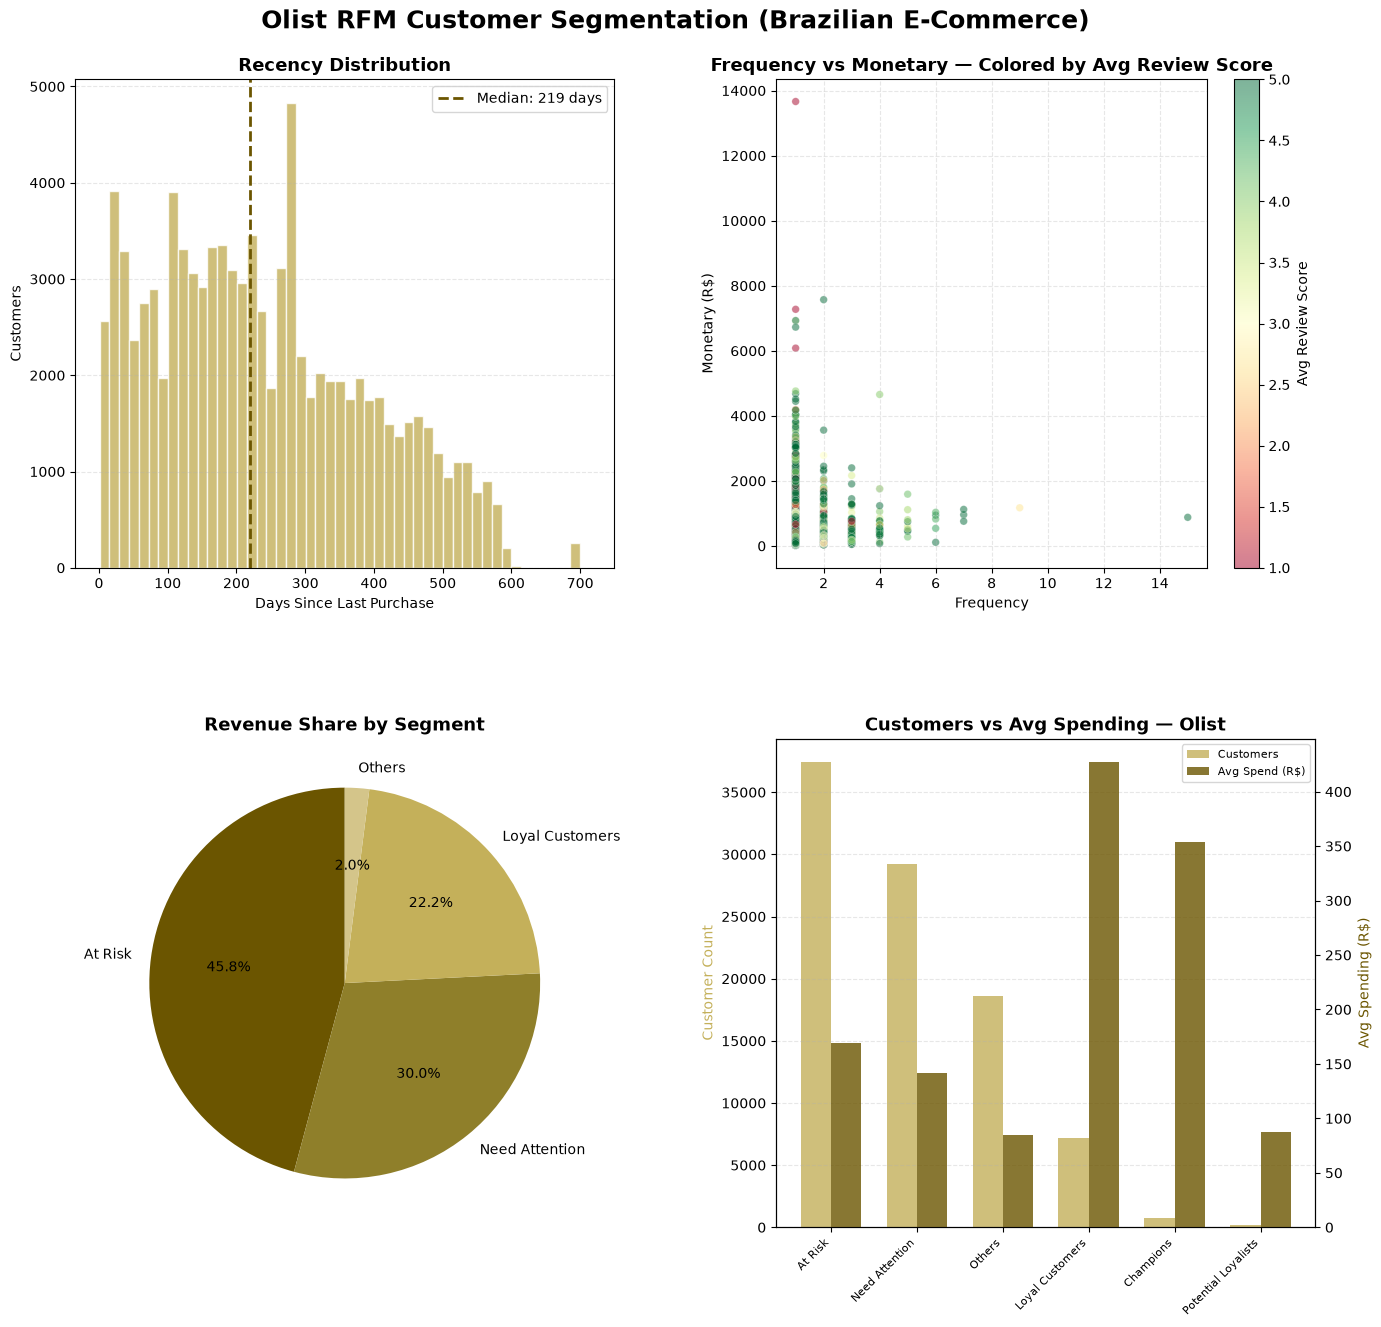

In [41]:
# ===== Cell 24：Olist RFM 四合一可视化 + vs UK 对比 =====

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Olist RFM Customer Segmentation (Brazilian E-Commerce)',
             fontsize=18, fontweight='bold', y=0.98)

highlight = '#6b5500'
secondary = '#c4b05a'

# 子图1：Recency 分布
ax1 = axes[0, 0]
ax1.hist(rfm['Recency'], bins=50, color=secondary, edgecolor='white', alpha=0.8)
ax1.axvline(rfm['Recency'].median(), color=highlight, linewidth=2,
            linestyle='--', label=f'Median: {rfm["Recency"].median():.0f} days')
ax1.set_title('Recency Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Days Since Last Purchase'); ax1.set_ylabel('Customers')
ax1.legend(); ax1.grid(axis='y', alpha=0.3, linestyle='--')

# 子图2：F vs M 散点图（加评分维度）
ax2 = axes[0, 1]
# 把平均评分 join 到 rfm 中
cust_avg_score = df.groupby('customer_unique_id')['review_score'].mean()
rfm_with_score = rfm.merge(cust_avg_score, on='customer_unique_id', how='left')
scatter = ax2.scatter(
    rfm_with_score['Frequency'], rfm_with_score['Monetary'],
    c=rfm_with_score['review_score'].fillna(3), cmap='RdYlGn',
    alpha=0.5, edgecolor='white', linewidth=0.3, s=30
)
ax2.set_xlabel('Frequency'); ax2.set_ylabel('Monetary (R$)')
ax2.set_title('Frequency vs Monetary — Colored by Avg Review Score', fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Avg Review Score', fontsize=10)
ax2.grid(alpha=0.3, linestyle='--')

# 子图3：营收占比饼图
ax3 = axes[1, 0]
seg_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
threshold = seg_rev.sum() * 0.02
seg_plot = seg_rev[seg_rev >= threshold].copy()
if seg_rev[seg_rev < threshold].sum() > 0:
    seg_plot['Others'] = seg_rev[seg_rev < threshold].sum()
ax3.pie(seg_plot.values, labels=seg_plot.index,
        colors=['#6b5500', '#8f7f2a', '#c4b05a', '#d4c58a', '#f8f4d9'][:len(seg_plot)],
        autopct='%1.1f%%', startangle=90)
ax3.set_title('Revenue Share by Segment', fontsize=13, fontweight='bold')

# 子图4：分段人数 vs 平均消费
ax4 = axes[1, 1]
seg_count = rfm.groupby('Segment').size().sort_values(ascending=False)
seg_avg_m = rfm.groupby('Segment')['Monetary'].mean().reindex(seg_count.index)
x = range(len(seg_count))
w = 0.35
ax4.bar([i - w/2 for i in x], seg_count.values, w, color=secondary, alpha=0.8, label='Customers')
ax4_twin = ax4.twinx()
ax4_twin.bar([i + w/2 for i in x], seg_avg_m.values, w, color=highlight, alpha=0.8, label='Avg Spend (R$)')
ax4.set_xticks(x); ax4.set_xticklabels(seg_count.index, rotation=45, ha='right', fontsize=8)
ax4.set_ylabel('Customer Count', color=secondary)
ax4_twin.set_ylabel('Avg Spending (R$)', color=highlight)
ax4.set_title('Customers vs Avg Spending — Olist', fontsize=13, fontweight='bold')
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.subplots_adjust(top=0.93, hspace=0.35, wspace=0.3)
plt.show()

In [42]:
# ===== Cell 25：Olist Cohort — 首次购买月份定义 =====

# 步骤1：提前准备 purchase_month 列
if 'purchase_month' not in df.columns:
    df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['OrderMonth'] = df['purchase_month'].astype(str)

# 步骤2：每个 customer_unique_id 的首次购买月份
# 关键区别：用 customer_unique_id，不是 customer_id
cohort_first = df.groupby('customer_unique_id')['OrderMonth'].min().reset_index()
cohort_first.columns = ['customer_unique_id', 'CohortMonth']

# 查看 Cohort 规模分布
cohort_sizes = cohort_first['CohortMonth'].value_counts().sort_index()
print("各月份新客数量（前5和后5）:")
print(cohort_sizes.head(5))
print("...")
print(cohort_sizes.tail(5))

各月份新客数量（前5和后5）:
CohortMonth
2016-09       1
2016-10     262
2016-12       1
2017-01     717
2017-02    1628
Name: count, dtype: int64
...
CohortMonth
2018-04    6582
2018-05    6506
2018-06    5875
2018-07    5946
2018-08    6144
Name: count, dtype: int64


In [43]:
# ===== Cell 25：Cohort 数据准备 =====

# 步骤1：每用户每月的消费记录（去重）
# df 中一行=一个商品项，多个商品项可能属于同一订单
# 先去重到 用户×月份 级别（同一用户同月多单 → 算一次）
df_cohort = df.groupby(
    ['customer_unique_id', 'purchase_month']
).size().reset_index()

df_cohort.columns = ['customer_unique_id', 'OrderMonth', 'Transactions']
# ^ Transactions 仅用于验证，后续不依赖

# 步骤2：每个用户的首月 = CohortMonth
cohort_first = df_cohort.groupby('customer_unique_id')['OrderMonth'].min().reset_index()
cohort_first.columns = ['customer_unique_id', 'CohortMonth']

# 步骤3：merge 进主表，计算 PeriodNumber
df_cohort = df_cohort.merge(cohort_first, on='customer_unique_id', how='left')

# PeriodNumber = 当前月份 - 队列月份（PeriodIndex 可以直接减，得到整数月份差）
df_cohort['PeriodNumber'] = (
    df_cohort['OrderMonth'].dt.to_timestamp() -
    df_cohort['CohortMonth'].dt.to_timestamp()
).dt.days // 30

# 步骤4：Cohort × Period 留存矩阵
# 每个 (CohortMonth, PeriodNumber) 中的独立客户数
cohort_matrix = df_cohort.groupby(
    ['CohortMonth', 'PeriodNumber']
)['customer_unique_id'].nunique().unstack()

# 留存率 = 当期人数 / 首期人数（PeriodNumber=0 是该队列的初始人数）
if 0 in cohort_matrix.columns:
    retention = cohort_matrix.divide(cohort_matrix[0], axis=0)
else:
    print("⚠ 警告：PeriodNumber=0 不在矩阵列中，检查数据")
    retention = cohort_matrix.divide(cohort_matrix.iloc[:, 0], axis=0)

# 去掉首尾不完整的队列（第一个月只有 1 单，最后几个月数据不完整）
# 保留队列人数 >= 50 的月份，确保统计稳定
cohort_sizes = cohort_matrix.get(0, cohort_matrix.iloc[:, 0])
valid_cohorts = cohort_sizes[cohort_sizes >= 50].index
retention = retention.loc[retention.index.isin(valid_cohorts)]

# 只保留前 12 期（一年），后面太稀疏
retention = retention.iloc[:, :12]

# CohortMonth 转字符串用于显示
retention.index = retention.index.astype(str)

print(f"Cohort 数量: {len(retention)}")
print(f"初始客户总数: {cohort_matrix[0].sum():,}")
print(f"\n留存矩阵 (前5行×前8列):")
print(retention.iloc[:5, :8].round(3))




Cohort 数量: 21
初始客户总数: 93,350.0

留存矩阵 (前5行×前8列):
PeriodNumber    0      1      2      3      4      5      6      7
CohortMonth                                                       
2016-10       1.0    NaN    NaN    NaN    NaN    NaN  0.004    NaN
2017-01       1.0  0.006    NaN  0.001  0.004  0.001  0.004  0.001
2017-02       1.0  0.003  0.001    NaN  0.004  0.001  0.002  0.002
2017-03       1.0  0.004  0.004  0.004  0.004  0.002  0.002  0.003
2017-04       1.0  0.006  0.002  0.002  0.003  0.003  0.004  0.003


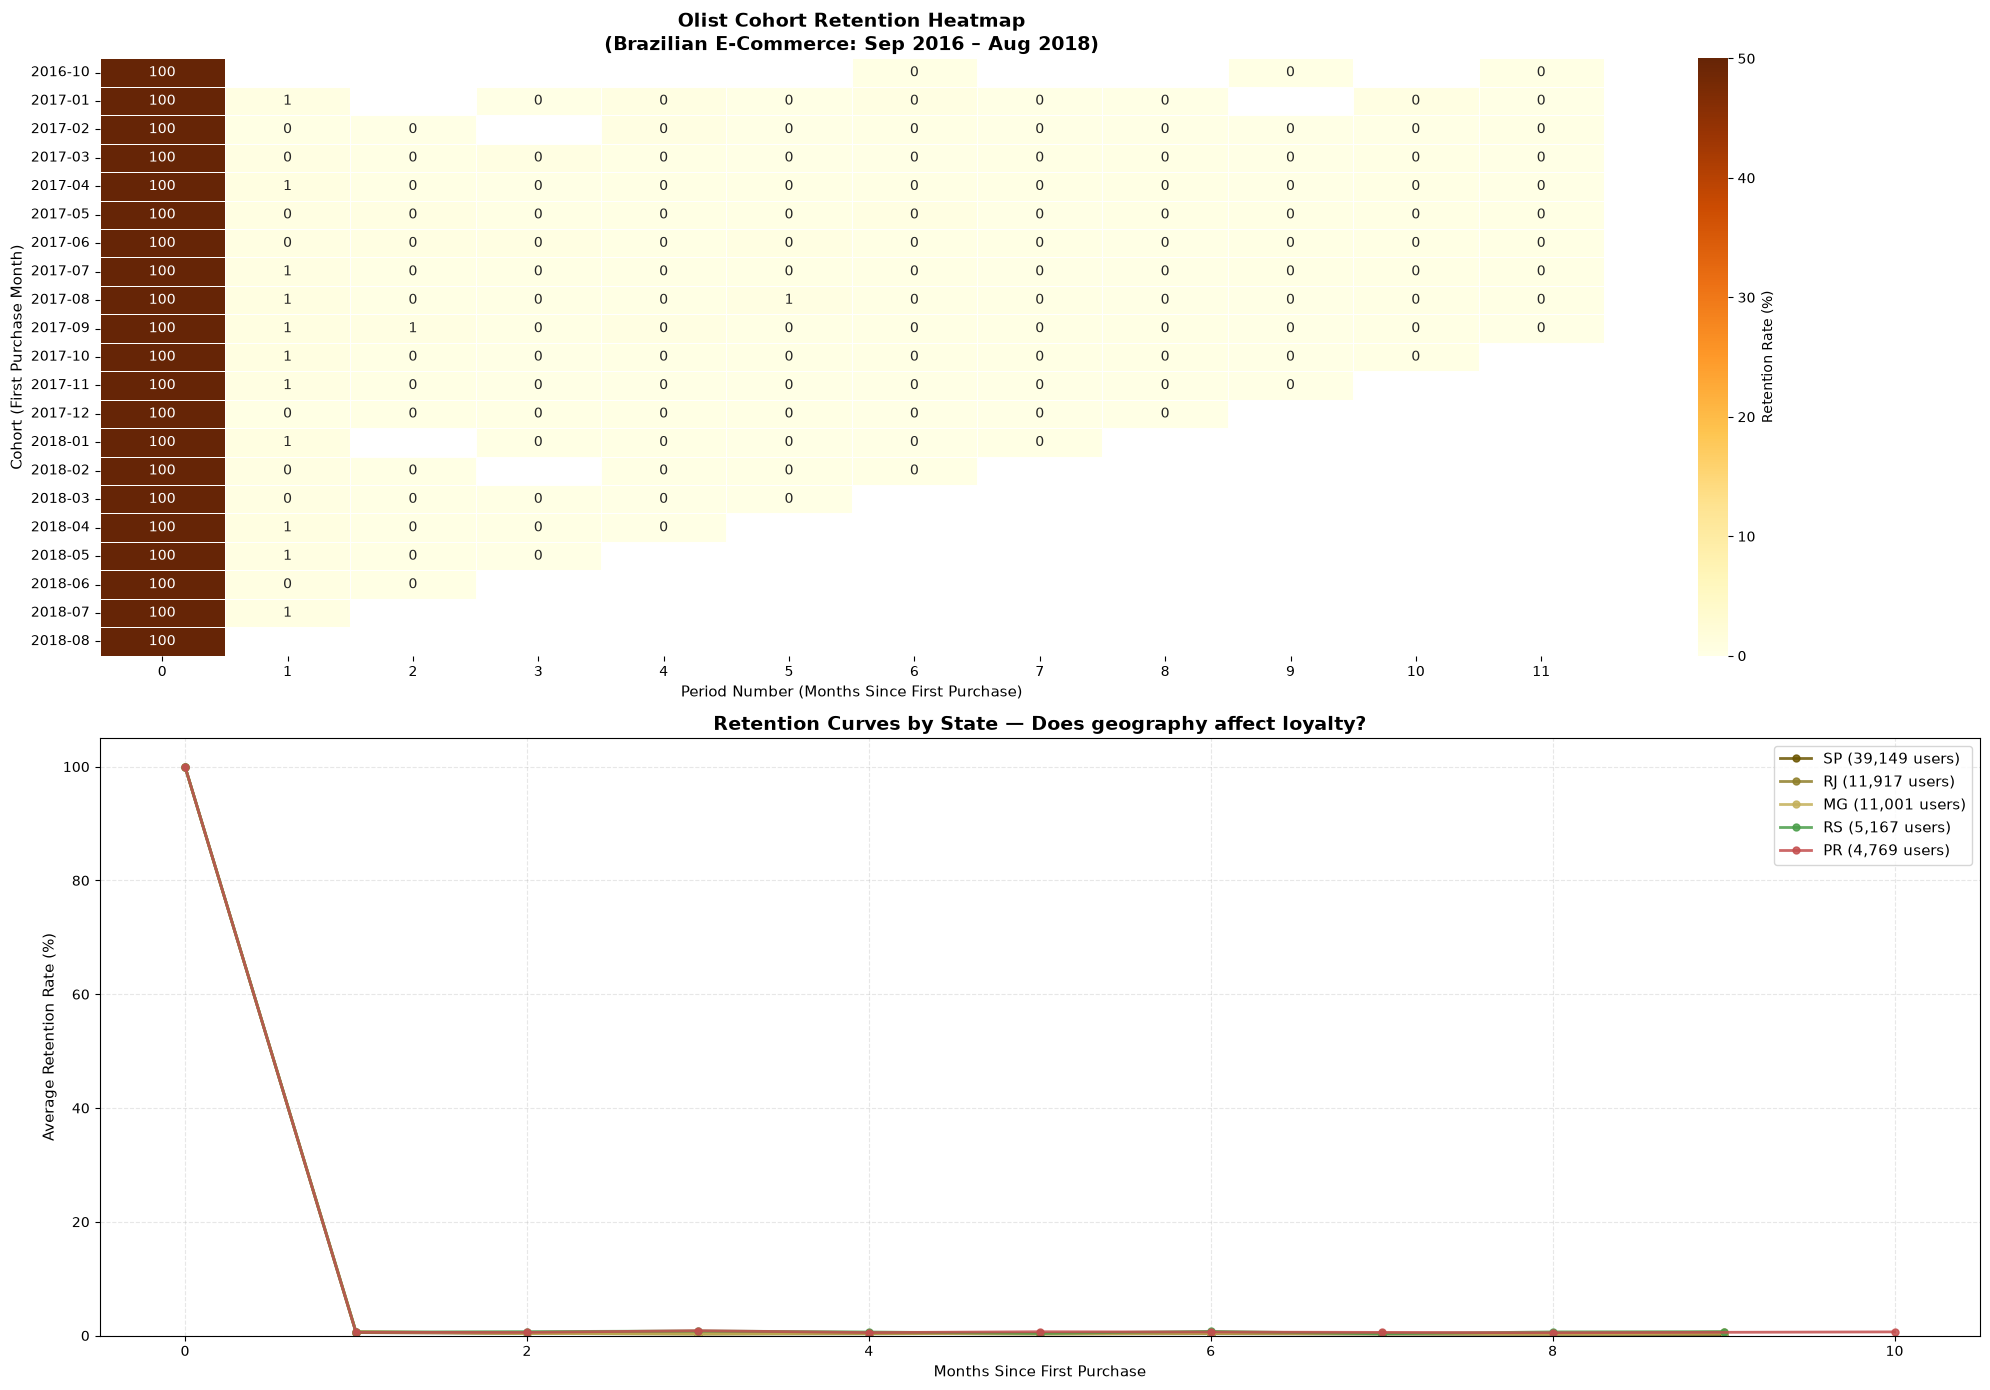

In [44]:
# ===== Cell 26：Olist Cohort 热力图 + 按州分组留存曲线 =====

fig = plt.figure(figsize=(20, 14))

highlight = '#6b5500'
secondary = '#c4b05a'

# --- 上图：留存率热力图 ---
ax1 = plt.subplot(2, 1, 1)
sns.heatmap(
    retention * 100,
    annot=True, fmt='.0f', cmap='YlOrBr',
    vmin=0, vmax=50,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Retention Rate (%)'},
    ax=ax1
)
ax1.set_title('Olist Cohort Retention Heatmap\n(Brazilian E-Commerce: Sep 2016 – Aug 2018)',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Period Number (Months Since First Purchase)', fontsize=11)
ax1.set_ylabel('Cohort (First Purchase Month)', fontsize=11)

# --- 下图：按州分组的平均留存曲线 ---
ax2 = plt.subplot(2, 1, 2)

# 取 Top 5 州
top_5_states = df['customer_state'].value_counts().head(5).index.tolist()
state_colors = ['#6b5500', '#8f7f2a', '#c4b05a', '#4a9e4a', '#c44e4e']

# 预先构建用户→州映射（避免循环内重复筛选）
user_state = df[['customer_unique_id', 'customer_state']].drop_duplicates()

for state, color in zip(top_5_states, state_colors):
    # 该州的客户列表
    state_users = user_state[user_state['customer_state'] == state]['customer_unique_id'].unique()

    # 直接在 df_cohort 上筛选，CohortMonth 和 PeriodNumber 已存在
    state_data = df_cohort[df_cohort['customer_unique_id'].isin(state_users)]

    # 构建该州的留存矩阵
    state_matrix = state_data.groupby(
        ['CohortMonth', 'PeriodNumber']
    )['customer_unique_id'].nunique().unstack()

    # 过滤队列人数 >= 20 的（州级队列人数少，阈值降低）
    if 0 in state_matrix.columns:
        valid_state_cohorts = state_matrix[state_matrix[0] >= 20].index
        state_matrix = state_matrix.loc[state_matrix.index.isin(valid_state_cohorts)]
        state_retention = state_matrix.divide(state_matrix[0], axis=0)
        state_avg = state_retention.mean(axis=0) * 100

        ax2.plot(state_avg.index[:10], state_avg.values[:10],
                 color=color, linewidth=2, marker='o', markersize=5,
                 label=f'{state} ({len(state_users):,} users)', alpha=0.85)

ax2.set_title('Retention Curves by State — Does geography affect loyalty?',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Months Since First Purchase', fontsize=11)
ax2.set_ylabel('Average Retention Rate (%)', fontsize=11)
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


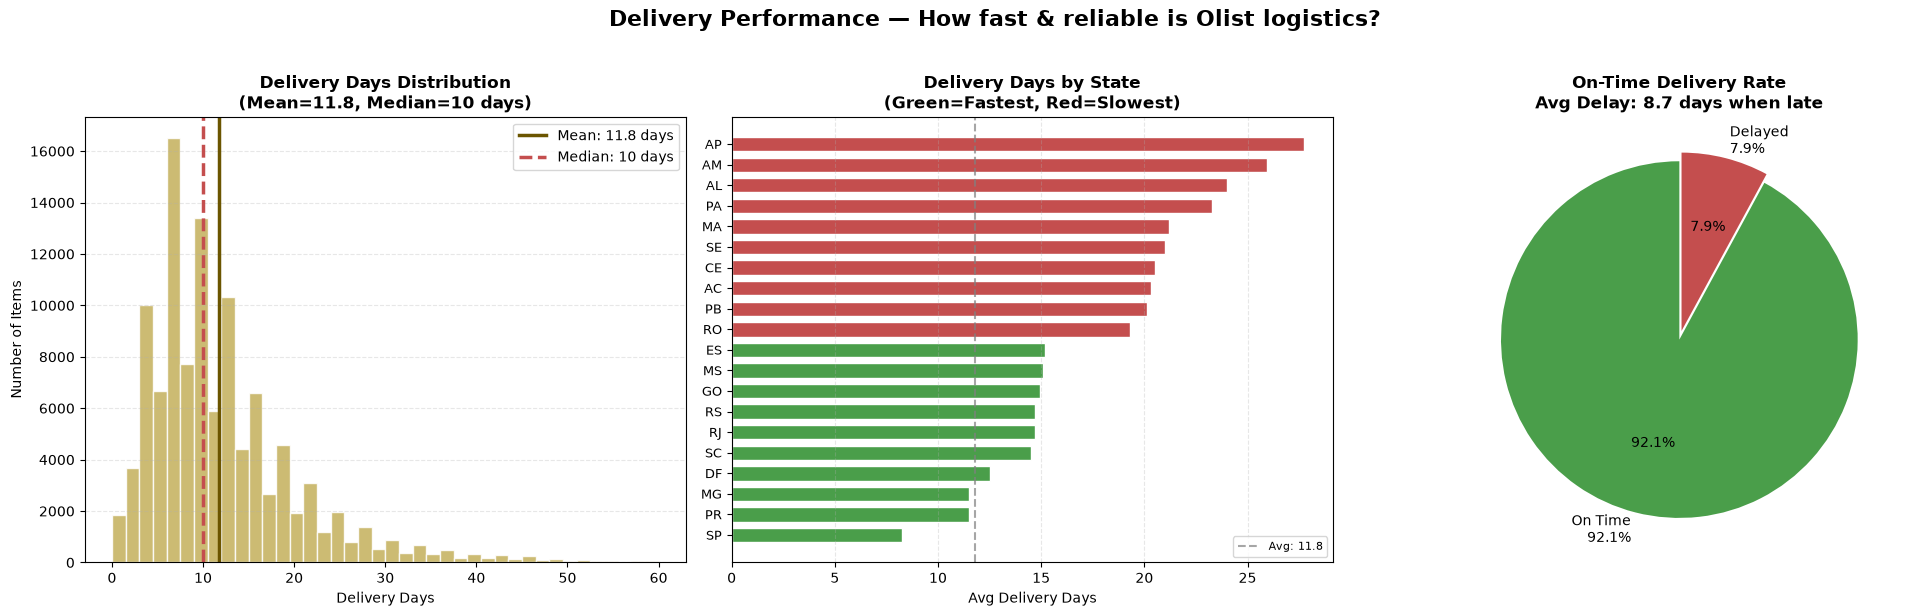

In [45]:
# ===== Cell 28：物流时效分布 + 超时分析 =====

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Delivery Performance — How fast & reliable is Olist logistics?',
             fontsize=16, fontweight='bold', y=1.02)

# --- 子图1：delivery_days 直方图 ---
ax1 = axes[0]
# 只看合理范围（0-60天），过滤掉极端长尾
valid_delivery = df[df['delivery_days'].between(0, 60)]
ax1.hist(valid_delivery['delivery_days'], bins=40, color='#c4b05a',
         edgecolor='white', alpha=0.85)
avg_d = valid_delivery['delivery_days'].mean()
med_d = valid_delivery['delivery_days'].median()
ax1.axvline(avg_d, color='#6b5500', linewidth=2.5, linestyle='-',
            label=f'Mean: {avg_d:.1f} days')
ax1.axvline(med_d, color='#c44e4e', linewidth=2.5, linestyle='--',
            label=f'Median: {med_d:.0f} days')
ax1.set_title(f'Delivery Days Distribution\n(Mean={avg_d:.1f}, Median={med_d:.0f} days)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Delivery Days'); ax1.set_ylabel('Number of Items')
ax1.legend(); ax1.grid(axis='y', alpha=0.3, linestyle='--')

# --- 子图2：各州平均配送天数对比 ---
ax2 = axes[1]
state_delivery = df.groupby('customer_state')['delivery_days'].mean().sort_values(ascending=False)
# 只画有 >=50 单的州
state_counts = df['customer_state'].value_counts()
valid_states_d = state_delivery[state_delivery.index.isin(
    state_counts[state_counts >= 50].index
)]
top_worst = valid_states_d.head(10).iloc[::-1]  # 最慢的10个州
top_best = valid_states_d.tail(10)               # 最快的10个州

all_states = pd.concat([top_best.iloc[::-1], top_worst])
colors_d = ['#4a9e4a'] * len(top_best) + ['#c44e4e'] * len(top_worst)
ax2.barh(range(len(all_states)), all_states.values, color=colors_d,
         edgecolor='white', height=0.7)
ax2.set_yticks(range(len(all_states)))
ax2.set_yticklabels(all_states.index, fontsize=9)
ax2.axvline(avg_d, color='gray', linestyle='--', alpha=0.7, label=f'Avg: {avg_d:.1f}')
ax2.set_title('Delivery Days by State\n(Green=Fastest, Red=Slowest)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Avg Delivery Days')
ax2.legend(fontsize=8); ax2.grid(axis='x', alpha=0.3, linestyle='--')

# --- 子图3：超时率 + 超时幅度 ---
ax3 = axes[2]
delay_pct = df['delivery_delayed'].mean() * 100
on_time_pct = 100 - delay_pct
ax3.pie([on_time_pct, delay_pct],
        labels=[f'On Time\n{on_time_pct:.1f}%', f'Delayed\n{delay_pct:.1f}%'],
        colors=['#4a9e4a', '#c44e4e'], autopct='%1.1f%%',
        startangle=90, explode=(0, 0.05))
# 超时幅度
delayed = df[df['delivery_delayed']]
delay_magnitude = (delayed['order_delivered_customer_date'] -
                    delayed['order_estimated_delivery_date']).dt.days
ax3.set_title(f'On-Time Delivery Rate\nAvg Delay: {delay_magnitude.mean():.1f} days when late',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

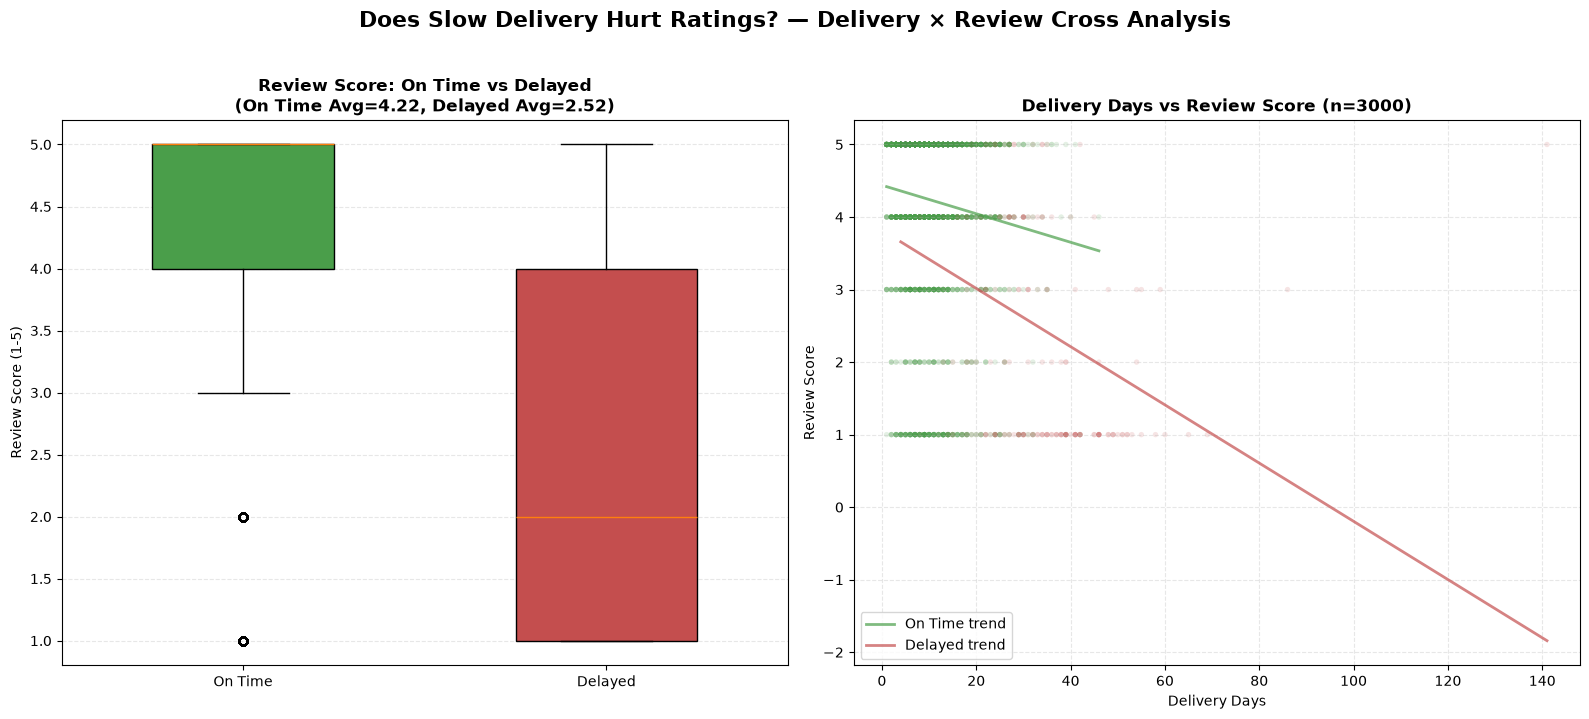

In [48]:
# ===== Cell 29：配送慢 → 评分低？（物流 × 评分散点图）=====

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Does Slow Delivery Hurt Ratings? — Delivery × Review Cross Analysis',
             fontsize=16, fontweight='bold', y=1.02)

# --- 左图：箱线图 ---
# x = 是否超时，y = 评分
df_valid_score = df[df['review_score'].notna()].copy()
df_valid_score['Delivery_Status'] = df_valid_score['delivery_delayed'].map(
    {True: 'Delayed', False: 'On Time'}
)
# 取采样（数据太多箱线图慢）
sample = df_valid_score.sample(min(5000, len(df_valid_score)), random_state=42)
bp = ax1.boxplot(
    [sample[sample['Delivery_Status'] == 'On Time']['review_score'],
     sample[sample['Delivery_Status'] == 'Delayed']['review_score']],
    tick_labels=['On Time', 'Delayed'],  # ← labels → tick_labels
    patch_artist=True, widths=0.5
)
bp['boxes'][0].set_facecolor('#4a9e4a')
bp['boxes'][1].set_facecolor('#c44e4e')
on_time_mean = sample[sample['Delivery_Status'] == 'On Time']['review_score'].mean()
delayed_mean = sample[sample['Delivery_Status'] == 'Delayed']['review_score'].mean()
ax1.set_title(f'Review Score: On Time vs Delayed\n(On Time Avg={on_time_mean:.2f}, Delayed Avg={delayed_mean:.2f})',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Review Score (1-5)'); ax1.grid(axis='y', alpha=0.3, linestyle='--')

# --- 右图：散点图 ---
# x = delivery_days, y = review_score (采样)
sample2 = df_valid_score.sample(min(3000, len(df_valid_score)), random_state=42)
ax2.scatter(
    sample2['delivery_days'], sample2['review_score'],
    c=sample2['delivery_delayed'].map({True: '#c44e4e', False: '#4a9e4a'}),
    alpha=0.15, s=15, edgecolor='none'
)
# 添加趋势参考线
for d in [0, 1]:
    subset = sample2[sample2['delivery_delayed'] == bool(d)]
    if len(subset) > 10:
        z = np.polyfit(subset['delivery_days'], subset['review_score'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(subset['delivery_days'].min(), subset['delivery_days'].max(), 100)
        ax2.plot(x_range, p(x_range), color=['#4a9e4a', '#c44e4e'][d],
                 linewidth=2, alpha=0.7, label=f'{"On Time" if d==0 else "Delayed"} trend')
ax2.set_xlabel('Delivery Days'); ax2.set_ylabel('Review Score')
ax2.set_title(f'Delivery Days vs Review Score (n={len(sample2)})',
              fontsize=12, fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()